In [150]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

old_mu = np.array([0.336, 0.189, 0.112, 0.063, 0.035, 0.018, 0.005]) 
new_mu = 8e10 * np.exp((-0.62)/(0.0259/300 * np.array([275, 270, 265, 260, 255, 250,245, 240])))
print("Old mu:", old_mu)
print("New mu:", new_mu)

Old mu: [0.336 0.189 0.112 0.063 0.035 0.018 0.005]
New mu: [0.36453466 0.2247573  0.13607029 0.08080349 0.04701334 0.02676725
 0.01489368 0.00808708]


Fitted parameters: A = 7.92e+10, Ea = 0.62 eV


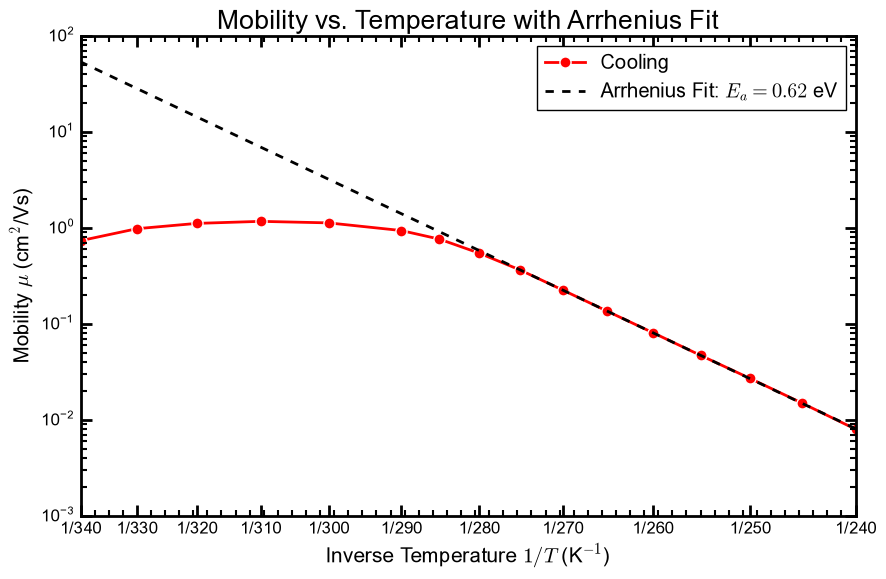

In [151]:
T_1 = np.array([340,330,320,310,300,290, 285,280,275,270,265,260,255, 250, 245, 240])
mu_1 = np.array([0.735, 0.980, 1.113, 1.169, 1.127, 0.938, 0.763, 0.546, 0.364, 0.225, 0.136, 0.081, 0.047, 0.027, 0.015, 0.008]) 





inv_T_ticks = 1 / np.array([340,330,320,310,300,290,280,270,260, 250, 240], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [340, 330, 320, 310, 300, 290, 280, 270, 260, 250, 240]]

def arrhenius(T, A, Ea):
    k_B = 8.617333262145e-5  # Boltzmann constant in eV/K
    return A * np.exp(-Ea / (k_B * T))


# fit only the last 6 points
T_fit_data = np.array(T_1[-7:], dtype=float)
mu_fit_data = np.array(mu_1[-7:], dtype=float)

popt, pcov = curve_fit(arrhenius, T_fit_data, mu_fit_data, p0=(1e-3, 0.1))
A_fit, Ea_fit = popt
print(f"Fitted parameters: A = {A_fit:.2e}, Ea = {Ea_fit:.2f} eV")

T_fit = np.linspace(240, 340, 100)
mu_fit = arrhenius(T_fit, *popt)

plt.semilogy(1/T_1, mu_1, marker='o', linestyle='-', lw=2, color='red',
             markeredgecolor="white", markeredgewidth=1, markersize=8, label='Cooling')
# plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw=2, color='blue',
#              markeredgecolor="white", markeredgewidth=1, markersize=8, label='Heating')
plt.plot(1/T_fit, mu_fit, linestyle='--', lw=2, color='black', label=rf'Arrhenius Fit: $E_a = {Ea_fit:.2f}$ eV')
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.xlim(1/340, 1/240)
plt.title('Mobility vs. Temperature with Arrhenius Fit', fontsize=19)
plt.legend(numpoints=1)
plt.savefig('arrhenius-1.eps', format='eps')
plt.savefig('arrhenius-1.png', format='png', dpi=600)
plt.show()

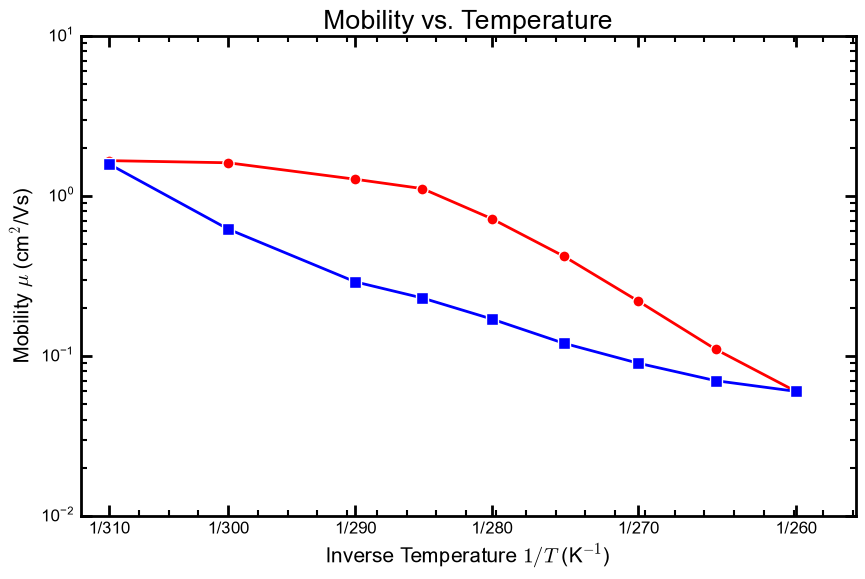

In [152]:
T_1 = [310,300,290, 285,280,275,270,265,260]
mu_1 = [1.66,1.61,1.27,1.11,0.72,0.42,0.22,0.11, 0.06]
V_T_1 = [45.81, 45.28, 46.39, 47.76, 51.50, 48.61, 45.90, 49.96, 56.03]

T_2 = [260, 265, 270, 275, 280, 285, 290, 300, 310]
mu_2 = [0.06, 0.07, 0.09, 0.12, 0.17, 0.23, 0.29, 0.62, 1.58]
V_T_2 = [56.03, 60.86, 60.48, 59.32, 60.83, 59.42, 59.32, 58.59, 54.08]
inv_T_1 = 1 / np.array(T_1, dtype=float)
inv_T_2 = 1 / np.array(T_2, dtype=float)
inv_T_ticks = 1 / np.array([310, 300, 290, 280, 270, 260], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [310, 300, 290, 280, 270, 260]]

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature', fontsize=19)
plt.savefig('mu-2.eps', format='eps')
plt.show()

# plt.plot(inv_T_1, V_T_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
# plt.plot(inv_T_2, V_T_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
# plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
# plt.ylabel(r'Threshold Voltage $V_T$ (V)')
# plt.xticks(inv_T_ticks, inv_T_ticklabels)
# plt.ylim(0, 100)  # Set y-axis limits for better visualization
# plt.title('Threshold Voltage vs. Temperature', fontsize=19)
# plt.savefig('VT-2.eps', format='eps')
# plt.show()

Fitted parameters: A = 4.90e+13, Ea = 0.77 eV


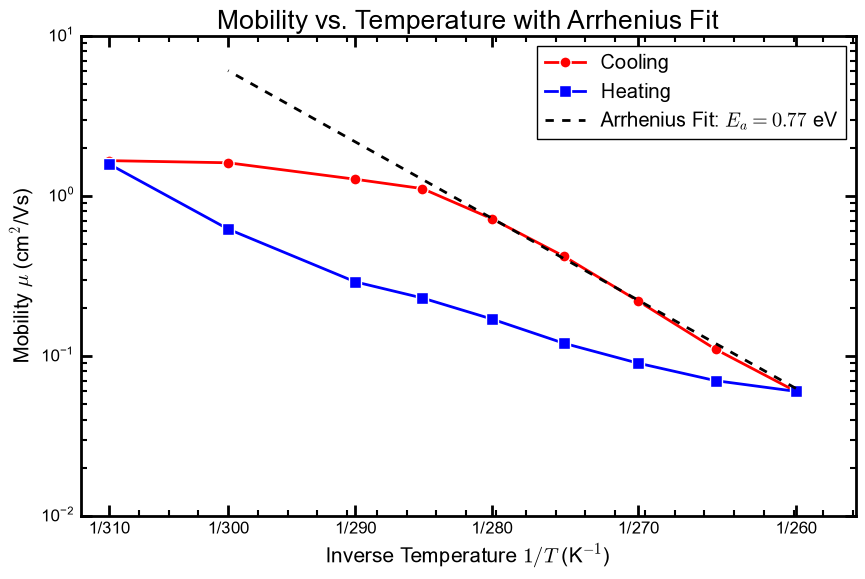

In [153]:
def arrhenius(T, A, Ea):
    k_B = 8.617333262145e-5  # Boltzmann constant in eV/K
    return A * np.exp(-Ea / (k_B * T))

# fit only the last 5 points
T_fit_data = np.array(T_1[-5:], dtype=float)
mu_fit_data = np.array(mu_1[-5:], dtype=float)

popt, pcov = curve_fit(arrhenius, T_fit_data, mu_fit_data, p0=(1e-3, 0.1))
A_fit, Ea_fit = popt
print(f"Fitted parameters: A = {A_fit:.2e}, Ea = {Ea_fit:.2f} eV")

T_fit = np.linspace(260, 300, 100)
mu_fit = arrhenius(T_fit, *popt)

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw=2, color='red',
             markeredgecolor="white", markeredgewidth=1, markersize=8, label='Cooling')
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw=2, color='blue',
             markeredgecolor="white", markeredgewidth=1, markersize=8, label='Heating')
plt.semilogy(1 / T_fit, mu_fit, linestyle='--', lw = 2, color='black', label=rf'Arrhenius Fit: $E_a = {Ea_fit:.2f}$ eV')
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature with Arrhenius Fit', fontsize=19)
plt.legend(numpoints=1)
plt.savefig('arrhenius-2.eps', format='eps')
plt.show()